# Machine Learning Model Benchmarking (Interactive Notebook)

This script loads the project config and cleaned training data, encodes the three-class labels (most likely disease-causing genes, probable disease-causing genes, and least likely disease-causing genes, all specific to blood pressure), and splits the data into train/test.

It computes class weights for balanced training, defines a set of candidate classifiers (**XGBoost**, **LightGBM**, **CatBoost**, **RandomForest**, **Logistic Regression**, **SVC**, and a small **neural network**) and their hyperparameter search spaces from the config.

For each model it runs **Bayesian hyperparameter optimization (BayesSearchCV)** with an inner CV, then evaluates tuned models with an outer CV, collecting metrics:

- balanced accuracy  
- f1_macro  
- precision_macro  
- recall_macro  

It also records per-fold balanced accuracies.

The script saves evaluation CSVs, selects the top-performing model(s), fits a final model and saves it. It runs **BorutaShap** on the training data to identify important features, and computes **SHAP explanations** to create and save class-level SHAP summary plots.

> **Note:** Hyperparameter tuning and Boruta+SHAP are computationally expensive. Ensure the conda environment contains required packages (`pandas`, `numpy`, `scikit-learn`, `scikeras`/`TensorFlow`, `xgboost`, `lightgbm`, `catboost`, `shap`, `skopt`, `seaborn`, `matplotlib`) and consider reducing iterations for quick experiments.


In [28]:
import os
os.chdir("/Users/hannahnicholls/GitHub/GenePrioritiser")

In [29]:
!python /Users/hannahnicholls/GitHub/GenePrioritiser/src/machine_learning/eda/eda_training_data.py

(247, 73)
Total columns (excluding 'Gene'): 71
Number of columns dropped due to missingness: 3
No high-separability features detected by AUC/ANOVA checks
Iteration: 0
Iteration: 1
Iteration: 2
label_encoded                              1.000000
RVIS_genic_intolerance                     0.259645
gene_damage_index_score                    0.116576
CellsEBVtransformedlymphocytes_GTExTPM     0.080785
NerveTibial_GTExTPM                        0.069949
                                             ...   
SkinSunExposedLowerleg_GTExTPM            -0.194227
SDI_essentiality                          -0.233291
SDI_Drug_Probability                      -0.238207
ExomiserScore_DecreasedBP_MultiHPOTerms   -0.264661
HIPred_haploinsufficiency                 -0.335295
Name: label_encoded, Length: 67, dtype: float64
Dropped features with > 0.9 correlation: ['KidneyCortex_GTExTPM', 'HeartAtrialAppendage_GTExTPM', 'EsophagusMuscularis_GTExTPM', 'ColonTransverse_GTExTPM', 'ColonSigmoid_GTExTPM', 'Cervix

In [22]:
# ============================================
# Standard libraries
# ============================================
import pandas as pd
import numpy as np
import pickle
import sys
import os
from pathlib import Path
import importlib
import importlib.machinery
import importlib.util

# ============================================
# Determine repo root (works even after os.chdir)
# ============================================
SCRIPT_DIR = Path().resolve()

# Search upward until we find the GenePrioritiser folder
def find_repo_root(start_path: Path, target="GenePrioritiser"):
    for parent in [start_path] + list(start_path.parents):
        if parent.name == target:
            return parent.resolve()
    raise RuntimeError(f"Could not locate repo root containing '{target}'")

ROOT_DIR = find_repo_root(SCRIPT_DIR)
print("Repo root detected as:", ROOT_DIR)

# Path to your real config
CONFIG_PATH = ROOT_DIR / "config" / "config.py"
print("Loading config from:", CONFIG_PATH)

# ============================================
# Explicitly load config.py under safe module name
# ============================================
loader = importlib.machinery.SourceFileLoader("gp_config", str(CONFIG_PATH))
spec = importlib.util.spec_from_loader(loader.name, loader)
gp_config = importlib.util.module_from_spec(spec)
loader.exec_module(gp_config)

print("Successfully loaded REAL config:", gp_config.__file__)

# ============================================
# Deep learning imports
# ============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from scikeras.wrappers import KerasClassifier

# ============================================
# Add EDA script path for custom MissForest
# ============================================
eda_script_path = Path(gp_config.eda_script_path).resolve()

if eda_script_path.exists():
    sys.path.append(str(eda_script_path))
else:
    print(f"WARNING: gp_config.eda_script_path does not exist → {eda_script_path}")

from updated_MissForest_Algorithm import MissForest

# ============================================
# Model selection + optimisation imports
# ============================================
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from skopt import BayesSearchCV

# ============================================
# Boosting models
# ============================================
import xgboost
from xgboost import XGBClassifier, plot_importance

import lightgbm
from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

# ============================================
# Classic ML models
# ============================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ============================================
# Preprocessing
# ============================================
from sklearn.preprocessing import StandardScaler

# ============================================
# Evaluation metrics
# ============================================
from sklearn.metrics import (
    make_scorer,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

# ============================================
# Add Boruta SHAP script path
# ============================================
boruta_path = Path(gp_config.boruta_shap_script).resolve()

if boruta_path.exists():
    sys.path.append(str(boruta_path))
else:
    print(f"WARNING: gp_config.boruta_shap_script does not exist → {boruta_path}")

from boruta_shap import UpdatedBorutaShap

# ============================================
# SHAP + plotting
# ============================================
import shap
import seaborn as sns
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

# ============================================
# Warnings
# ============================================
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")

# ============================================
# Random seed
# ============================================
seed = 0


Repo root detected as: /Users/hannahnicholls/GitHub/GenePrioritiser
Loading config from: /Users/hannahnicholls/GitHub/GenePrioritiser/config/config.py
Successfully loaded REAL config: /Users/hannahnicholls/GitHub/GenePrioritiser/config/config.py


In [30]:
dataset = pd.read_csv(gp_config.training_genes, sep="\t")
data = dataset.drop(["Gene"], axis=1)  
data["label_encoded"] = data["label"].map({"most likely": 0, "probable": 1, "least likely": 2})
Y = data["label_encoded"]

data = pd.read_csv(gp_config.cleaned_training_data_ml, header=0, sep=",")
Y = data["label_encoded"]

X = pd.read_csv(gp_config.cleaned_training_data_ml, header=0, sep=",")
X = X.drop(['Gene', "label_encoded"], axis=1)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=seed)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

class_weights = compute_class_weight('balanced', classes=np.unique(Y_train), y=Y_train)
weight_dict = dict(zip(np.unique(Y_train), class_weights))

def create_nn_model():
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))  # Explicit Input layer
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

nn_model = KerasClassifier(model=create_nn_model, epochs=50, batch_size=32, verbose=0)

models = [
    ('XGB', XGBClassifier(random_state=seed, objective='multi:softmax', num_class=3, eval_metric='mlogloss')),
    ('LGBM', LGBMClassifier(random_state=seed, verbose=-1, class_weight='balanced')),
    ('CatBoost', CatBoostClassifier(random_seed=seed, verbose=False, auto_class_weights='Balanced')),
    ('RF', RandomForestClassifier(random_state=seed, class_weight='balanced')),
        # increase max_iter and use saga solver to reduce convergence warnings on large data
        ('LR', LogisticRegression(random_state=seed, multi_class='multinomial', class_weight='balanced', solver='saga', max_iter=2000)),
    ('SVC', SVC(random_state=seed, probability=True, class_weight='balanced')),
    ('NN', nn_model)
]

params = {
    'XGB': gp_config.xgb_parameters,
    'LGBM': gp_config.lgbm_parameters,
    'CatBoost': gp_config.catboost_parameters,
    'RF': gp_config.rf_parameters,
    'LR': gp_config.lr_parameters,
    'SVC': gp_config.svc_parameters,
    'NN': gp_config.nn_parameters
}


inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

scoring_metrics = {'balanced_accuracy': 'balanced_accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}

model_details = []
fold_balanced_accuracies = []

In [31]:
for name, model in models:
    if name in ['LR', 'SVC', 'NN']:
        X_tr, Y_tr = X_train_scaled, Y_train
    else:
        X_tr, Y_tr = X_train, Y_train
    
        bs_n_jobs = -1 if name != 'NN' else 1
        search = BayesSearchCV(model, params[name], n_iter=10, cv=inner_cv, n_jobs=bs_n_jobs, random_state=seed)
    search.fit(X_tr, Y_tr)
    
    cv_results = cross_validate(search, X_tr, Y_tr, cv=outer_cv, scoring=scoring_metrics)
    model_details.append((name, search.best_params_, cv_results))

    fold_balanced_accuracies.append(cv_results['test_balanced_accuracy'])

# Create DataFrame to store balanced accuracy for each fold for each model
fold_balanced_accuracies_df = pd.DataFrame(fold_balanced_accuracies, index=[name for name, _ in models])
fold_balanced_accuracies_df.columns = [f'Fold_{i+1}' for i in range(fold_balanced_accuracies_df.shape[1])]

# Save the DataFrame as a CSV file
fold_balanced_accuracies_df.to_csv(gp_config.balanced_accuracy_per_fold, index=True)

results_df = pd.DataFrame()

for name, best_params, cv_results in model_details:
    for metric in scoring_metrics:
        mean_score = np.mean(cv_results[f'test_{metric}'])
        print(f"{name} - {metric}: {mean_score}")
    print(f"{name} Best Parameters: {best_params}\n")
    df = pd.DataFrame({
        'model': [name],
        'balanced_accuracy': [np.mean(cv_results['test_balanced_accuracy'])],
        'f1_macro': [np.mean(cv_results['test_f1_macro'])],
        'precision_macro': [np.mean(cv_results['test_precision_macro'])],
        'recall_macro': [np.mean(cv_results['test_recall_macro'])]
    })
    results_df = pd.concat([results_df, df], ignore_index=True)

results_df.to_csv(gp_config.ml_eval_metrics_class_weighted, index=False)

# Find the top 3 performing models based on balanced accuracy
top_3_models = sorted(model_details, key=lambda x: np.mean(x[2]['test_balanced_accuracy']), reverse=True)[:3]

XGB - balanced_accuracy: 0.5782206119162641
XGB - f1_macro: 0.58056953968485
XGB - precision_macro: 0.6147961254746572
XGB - recall_macro: 0.5782206119162641
XGB Best Parameters: OrderedDict([('learning_rate', 0.18124529162241818), ('max_depth', 3), ('n_estimators', 27)])

LGBM - balanced_accuracy: 0.6553103498755674
LGBM - f1_macro: 0.6563257170530441
LGBM - precision_macro: 0.6752537607635647
LGBM - recall_macro: 0.6553103498755674
LGBM Best Parameters: OrderedDict([('learning_rate', 0.12316281457812761), ('max_depth', 4), ('n_estimators', 39)])

CatBoost - balanced_accuracy: 0.6555116381203338
CatBoost - f1_macro: 0.6135206580135977
CatBoost - precision_macro: 0.6082504532504533
CatBoost - recall_macro: 0.6555116381203338
CatBoost Best Parameters: OrderedDict([('depth', 4), ('iterations', 50), ('learning_rate', 0.0899879006372652)])

RF - balanced_accuracy: 0.6552883911579563
RF - f1_macro: 0.6560464725701346
RF - precision_macro: 0.6770979020979021
RF - recall_macro: 0.655288391157

In [32]:
best_model_info = top_3_models[0]
best_model_name, best_model_params, _ = best_model_info
best_model = models[[m[0] for m in models].index(best_model_name)][1]
best_model.set_params(**best_model_params)
best_model.fit(X_train, Y_train)

output_dir = gp_config.ml_output_path


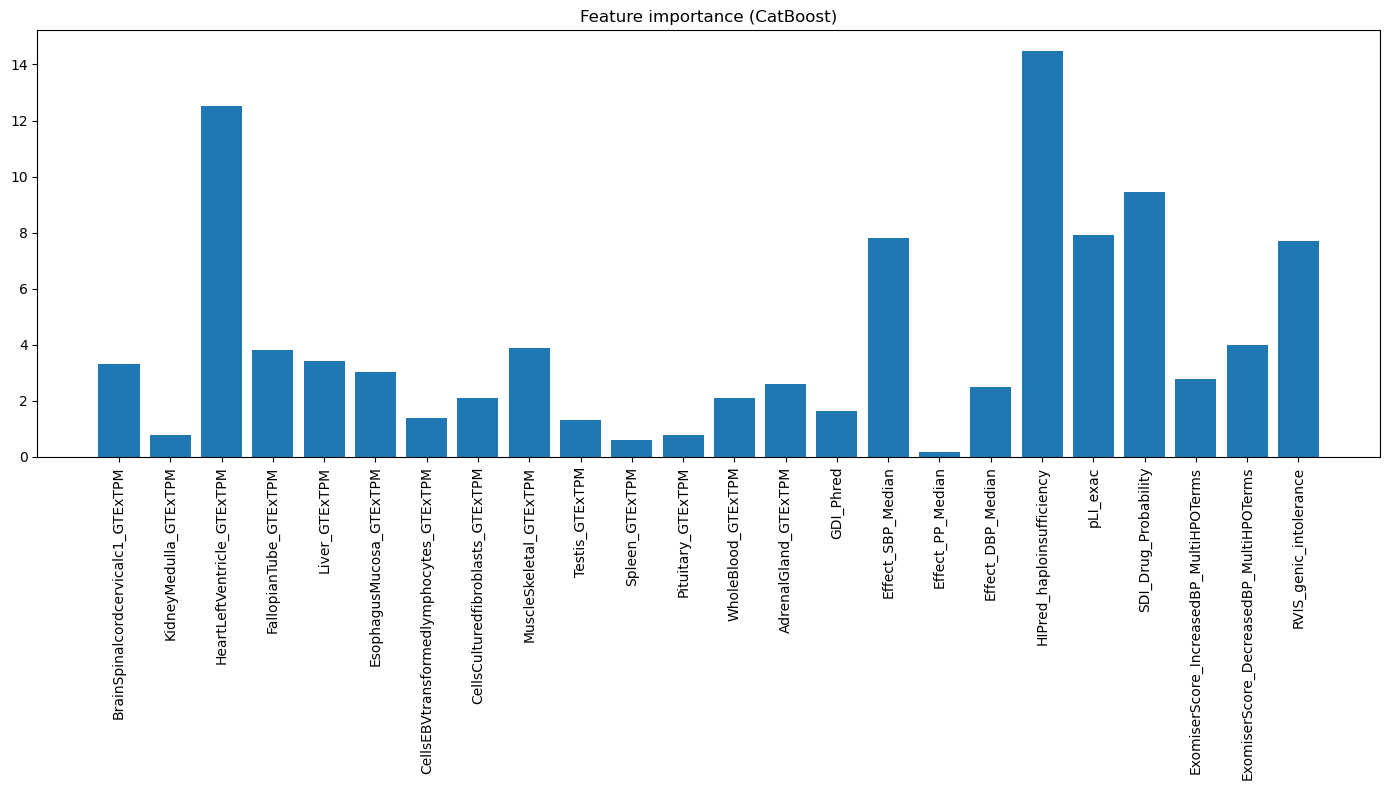

In [33]:
if best_model_name == 'XGB':
    plt.figure(figsize=(14, 8))
    xgboost.plot_importance(
        best_model,
        importance_type='weight',
        title='Feature importance (XGBoost - by weight)'
    )
    plt.tight_layout()
    plt.show()


elif best_model_name == 'LGBM':
    # Split importance
    plt.figure(figsize=(14, 8))
    lightgbm.plot_importance(
        best_model,
        importance_type='split',
        title='Feature importance (LightGBM - by split)'
    )
    plt.tight_layout()
    plt.show()

    # Gain importance
    plt.figure(figsize=(14, 8))
    lightgbm.plot_importance(
        best_model,
        importance_type='gain',
        title='Feature importance (LightGBM - by gain)'
    )
    plt.tight_layout()
    plt.show()


elif best_model_name == 'CatBoost':
    feature_importances = best_model.get_feature_importance(type="FeatureImportance")
    feature_names = X_train.columns

    plt.figure(figsize=(14, 8))
    plt.bar(range(len(feature_importances)), feature_importances)
    plt.xticks(
        ticks=range(len(feature_names)),
        labels=feature_names,
        rotation='vertical'
    )
    plt.title('Feature importance (CatBoost)')
    plt.tight_layout()
    plt.show()


else:
    print(f"No feature importance plotting is available for the model {best_model_name}.")


  0%|          | 0/100 [00:00<?, ?it/s]

8 attributes confirmed important: ['HeartLeftVentricle_GTExTPM', 'WholeBlood_GTExTPM', 'Liver_GTExTPM', 'pLI_exac', 'AdrenalGland_GTExTPM', 'Effect_SBP_Median', 'HIPred_haploinsufficiency', 'RVIS_genic_intolerance']
16 attributes confirmed unimportant: ['Spleen_GTExTPM', 'Testis_GTExTPM', 'KidneyMedulla_GTExTPM', 'CellsCulturedfibroblasts_GTExTPM', 'GDI_Phred', 'ExomiserScore_DecreasedBP_MultiHPOTerms', 'BrainSpinalcordcervicalc1_GTExTPM', 'CellsEBVtransformedlymphocytes_GTExTPM', 'Effect_DBP_Median', 'MuscleSkeletal_GTExTPM', 'Pituitary_GTExTPM', 'SDI_Drug_Probability', 'ExomiserScore_IncreasedBP_MultiHPOTerms', 'FallopianTube_GTExTPM', 'EsophagusMucosa_GTExTPM', 'Effect_PP_Median']
0 tentative attributes remains: []


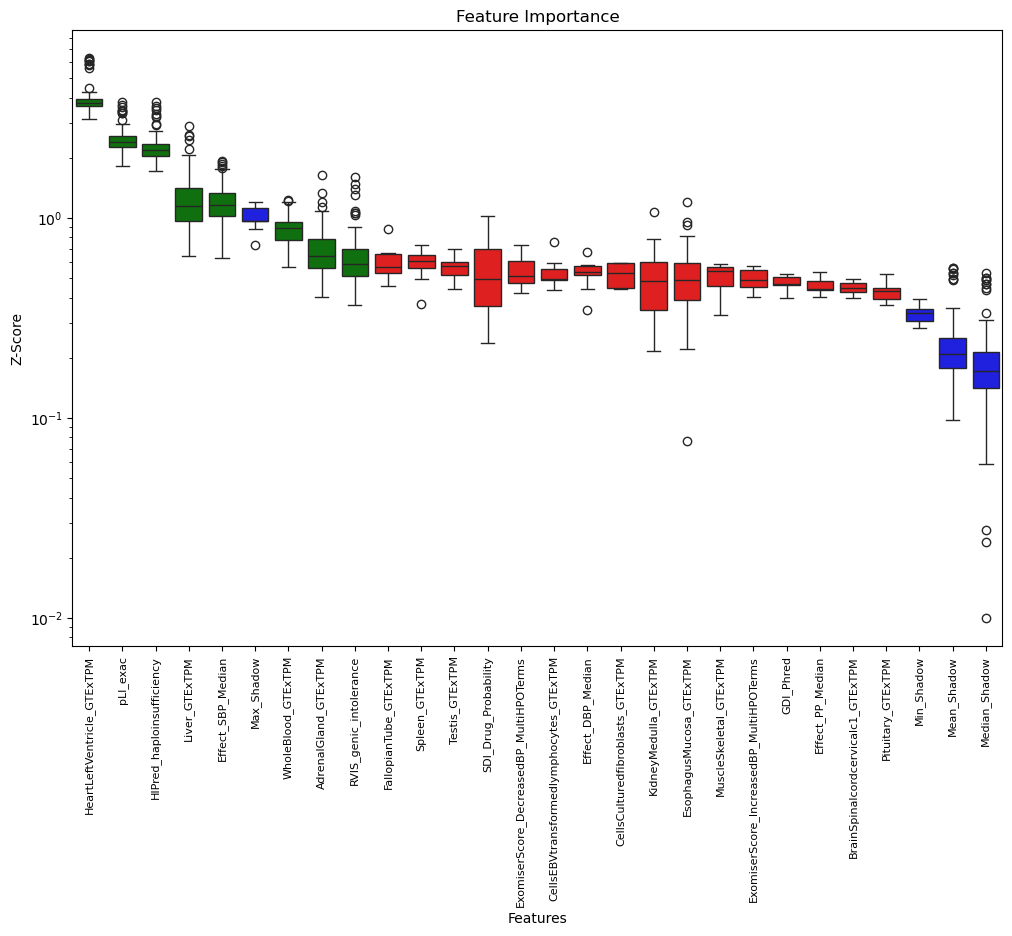

<Figure size 640x480 with 0 Axes>

In [34]:
# Run BorutaSHAP
Feature_Selector = UpdatedBorutaShap(
    importance_measure="shap",
    classification=False
)

Feature_Selector.fit(
    X=X_train,
    y=Y_train,
    n_trials=100,
    random_state=seed
)

# Display plot in notebook
Feature_Selector.plot(display=True)

# Get the current figure AFTER plot() runs
fig = plt.gcf()




In [36]:
print('Saving best model...')
best_model.fit(X, Y)
filename = gp_config.best_model_pkl_file
with open(filename, 'wb') as file:
    pickle.dump(best_model, file)

Saving best model...


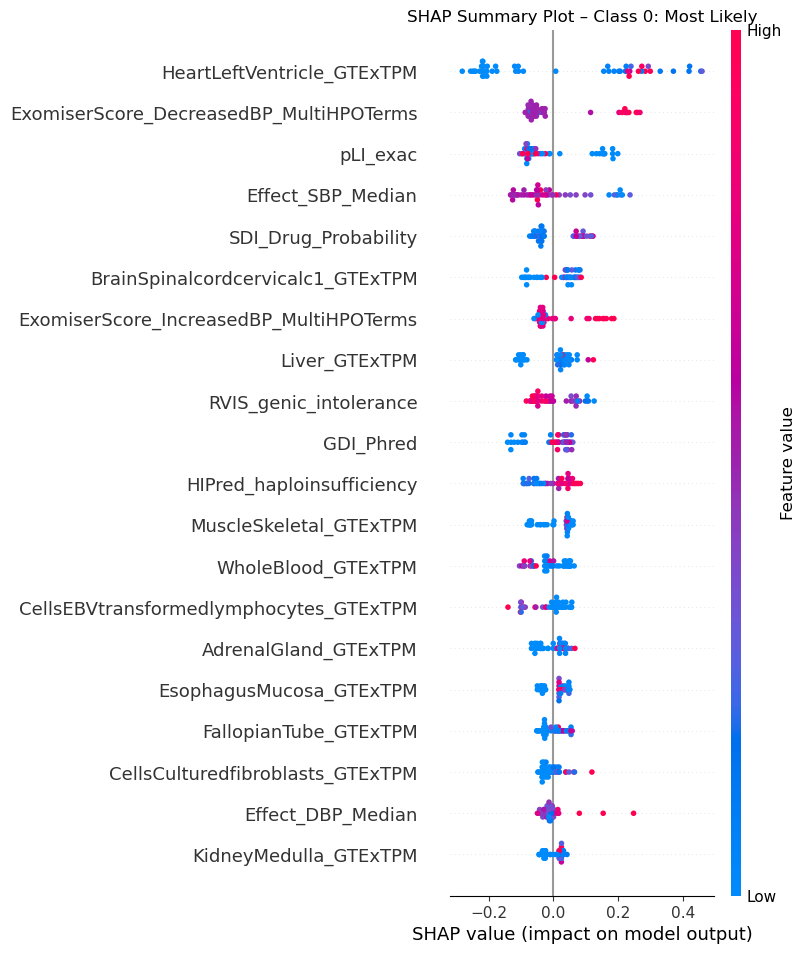

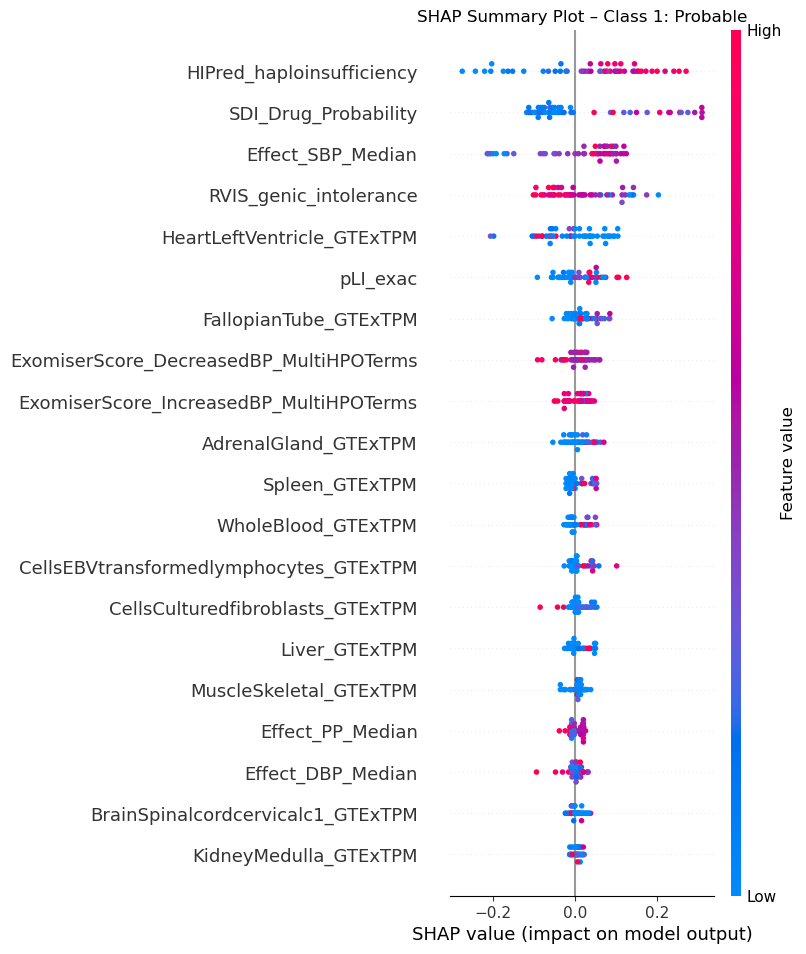

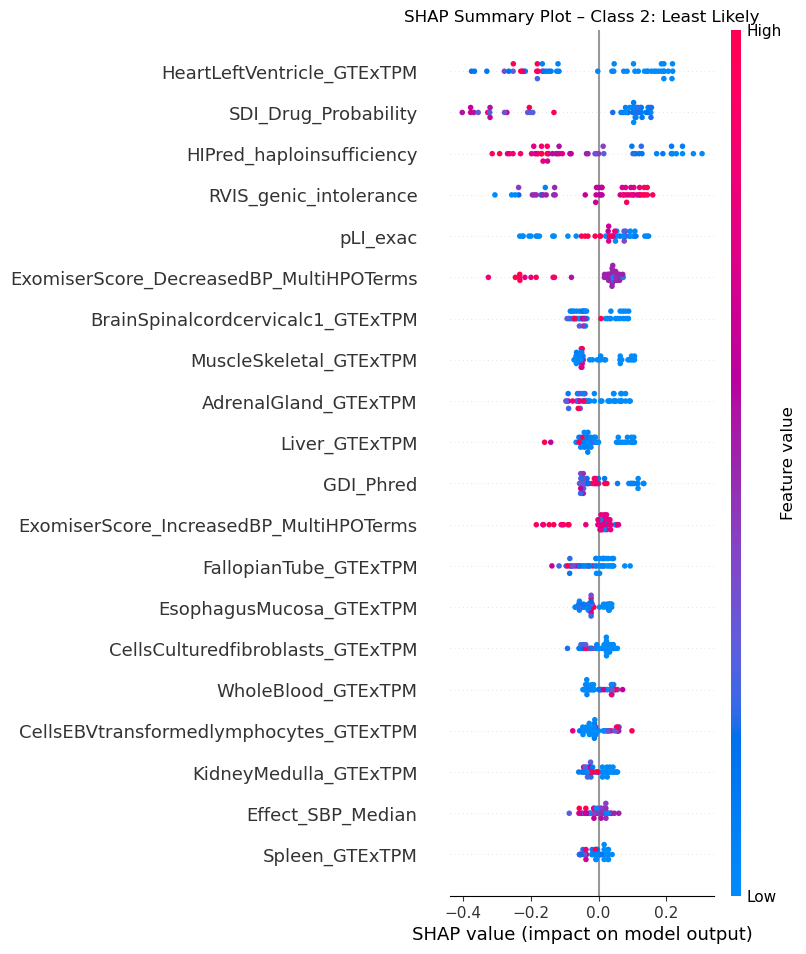

In [37]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Optional: map class index → label name
class_names = ["Most Likely", "Probable", "Least Likely"]

for class_idx in range(len(shap_values)):
    plt.figure(figsize=(10, 6))

    # Display SHAP summary plot
    shap.summary_plot(
        shap_values[class_idx],
        X_test,
        show=False  # Let us control display & title manually
    )

    # Add a title for the class
    plt.title(f"SHAP Summary Plot – Class {class_idx}: {class_names[class_idx]}")

    # Now show in notebook
    plt.show()

    # Save
    fig = plt.gcf()
    fig.savefig(
        f"{output_dir}/shap_summary_class_{class_idx}.png",
        bbox_inches='tight',
        dpi=300
    )

    plt.close(fig)
